# Imports

In [1]:
import shutil
import os

from scattertools.support import molstat
#from scattertools.infotheory import entropy

print(os.getcwd())

/Users/frank/Documents/programming/scattertools/examples/information_theory/simulate_data/refl1d


# Create Short Example Fit

A functional fit needs to be provided loading simX.dat data files. Currently, the information theory package requires all parameters to be defined using the Parameter() method, and names should not contain spaces. Solvent nSLDs need to be named rho_solv_X to allow the correct background scattering to be calculated.

In [2]:
%%writefile ssblm.py
## === Import section ===
import sys
# append path to your molgroups, or just link molgroups to your same directory
import numpy as np
from molgroups import mol
from molgroups import lipids
from molgroups import components as cmp
from refl1d.names import load4, Parameter, SLD, Slab, Stack, Experiment, FitProblem
from refl1d.sample.flayer import FunctionalProfile

## === Film structure definition section ===

### Bilayer profile definition function

def bilayer(z, sigma, bulknsld, global_rough, rho_substrate, l_submembrane, l_lipid1, l_lipid2, vf_bilayer):
    """ Fairly generic bilayer. This assumes a stack of materials already existing because siox.l is set to zero """
    
    # Set unused parameters
    l_siox = 0.0 # could make a parameter in the future
    rho_siox = 0.0

    # Scale all SLDs from Refl1D units (1e-6 Ang^-2) to molgroups units (Ang^-2)
    bulknsld *= 1e-6
    rho_substrate *= 1e-6

    blm.fnSet(sigma=sigma, bulknsld=bulknsld, global_rough=global_rough, rho_substrate=rho_substrate, rho_siox=rho_siox, l_siox=l_siox,
              l_submembrane=l_submembrane, l_lipid1=l_lipid1, l_lipid2=l_lipid2, vf_bilayer=vf_bilayer)
    
    # Calculate scattering properties of volume occupied by bilayer
    normarea, area, nsl = blm.fnWriteProfile(z)

    # Fill in the remaining volume with buffer of appropriate nSLD
    nsld = nsl / (normarea * np.gradient(z)) + (1.0 - area / normarea) * bulknsld

    # Return nSLD profile in Refl1D units
    return nsld*1e6

### Define bilayer parameters
vf_bilayer = Parameter(name='volume_fraction_bilayer', value=0.9).range(0.0, 1.0)
l_lipid1 = Parameter(name='inner_acyl_chain_thickness', value=10.0).range(8, 16)
l_lipid2 = Parameter(name='outer_acyl_chain_thickness', value=10.0).range(8, 16)
sigma = Parameter(name='bilayer_roughness', value=5).range(2, 9)
global_rough = Parameter(name ='tiox_roughness', value=5).range(2, 9)
l_tiox = Parameter(name='total_tiox_thickness', value=120).range(50, 150)
l_submembrane = Parameter(name='submembrane_thickness', value=10).range(0, 50)

### Define bilayer object
blm = mol.ssBLM(lipids=[lipids.DOPC], lipid_nf=[1.0])

### Define molgroups space.
dimension=300       # Number of steps
stepsize=0.5        # Length of steps

## === Stack ===
##
## First, we create a 'material' for each bulk layer, which has an real and imaginary
## scattering length density, stored in a Refl1d object called 'SLD'
d2o = SLD(name='d2o', rho=6.3000, irho=0.0000)
h2o = SLD(name='h2o', rho=-0.56, irho=0.0000)
tiox = SLD(name='tiox', rho=2.1630, irho=0.0000)
siox = SLD(name='siox', rho=4.1000, irho=0.0000)
silicon = SLD(name='silicon', rho=2.0690, irho=0.0000)

## Then bulk layers are created, each with its own 'material'.  If you want to force
## two layers to always match SLD you can use the same material in multiple layers.
## The roughnesses of each layer are set to zero to begin with:

layer_d2o = Slab(material=d2o, thickness=0.0000, interface=5.0000)
layer_h2o = Slab(material=h2o, thickness=0.0000, interface=5.0000)
layer_tiox = Slab(material=tiox, thickness=l_tiox - (blm.substrate.z + 0.5 * blm.substrate.length), interface=0.0)
layer_siox = Slab(material=siox, thickness=7.5804, interface=10.000)
layer_silicon = Slab(material=silicon, thickness=0.0000, interface=0.0000)

## Set sample parameter ranges and constraints between layer properties
# layer roughness parameters
###################################################################
## the 'interface' associated with layer0 is the boundary between #
## layer0 and layer1, and similarly for layer(N) and layer(N+1)   #
###################################################################
layer_siox.interface = siox_interface = Parameter(name='siox_interface', value=5.0).range(2.0000, 9.000)

# Si and SiOx roughnesses are the same
layer_silicon.interface = layer_siox.interface

# nSLD parameters
d2o.rho = rho_d2o = Parameter(name='rho_solv_0', value=6.34).range(5.3000, 6.5000)
h2o.rho = rho_h2o = Parameter(name='rho_solv_1', value=-0.56).range(-0.6, 0.6)
tiox.rho = rho_tiox = Parameter(name='rho_tiox', value=2).range(1.1630, 3.1630)
siox.rho = rho_siox = Parameter(name='rho_siox', value=3.5).range(3.1000, 5.1000)

# layer thickness parameters
layer_tiox.thickness = tiox_thickness = Parameter(name='tiox_thickness', value=100.).range(66.379, 266.38)
layer_siox.thickness = siox_thickness = Parameter(name='siox_thickness', value=30.).range(5, 40)

## Use the bilayer definition function to generate the bilayer SLD profile, passing in the relevant parameters.
## Note that substrate and bulk SLDs are linked to their respective materials.
mollayer = FunctionalProfile(dimension*stepsize, 0, profile=bilayer, sigma=sigma,
                                bulknsld=d2o.rho, global_rough=global_rough, rho_substrate=tiox.rho,
                                l_submembrane=l_submembrane, l_lipid1=l_lipid1, l_lipid2=l_lipid2,
                                vf_bilayer=vf_bilayer)
mollayerh = FunctionalProfile(dimension*stepsize, 0, profile=bilayer, sigma=sigma,
                                bulknsld=h2o.rho, global_rough=global_rough, rho_substrate=tiox.rho,
                                l_submembrane=l_submembrane, l_lipid1=l_lipid1, l_lipid2=l_lipid2,
                                vf_bilayer=vf_bilayer)

## Stack the layers into individual samples, using common layer objects for layers that are unchanged between samples
## As a convention, always build the sample from the substrate up. If the neutron beam is incident from the substrate side,
## set back_reflectivity = True in the probe definition later.

sample = layer_silicon | layer_siox | layer_tiox | mollayer | layer_d2o
sampleh = layer_silicon | layer_siox | layer_tiox | mollayerh | layer_h2o

## === Data files ===
probe = load4('sim0.dat', back_reflectivity=True)
probeh = load4('sim1.dat', back_reflectivity=True)

# Set instrumental (probe) parameters
probe.background = background_0 = Parameter(name='background_0', value=0.).range(-1e-7, 1e-5)
probeh.background = background_1 = Parameter(name='background_1', value=0.).range(-1e-7, 1e-5)
probe.intensity = intensity = Parameter(name='intensity', value=1.0).range(0.9, 1.05)
probeh.intensity = probe.intensity
probe.theta_offset = theta_offset = Parameter(name='theta_offset', value=0.).range(-0.015, 0.005)
probeh.theta_offset = probe.theta_offset
probe.sample_broadening = sample_broadening = Parameter(name='sample_broadening', value=0).range(-0.005, 0.02)
probeh.sample_broadening = probe.sample_broadening

# Define critical edge oversampling for samples that require it
# probe.critical_edge(substrate=silicon, surface=d2o)

## === Problem definition ===
## a model object consists of a sample and a probe.

## step = True corresponds to a calculation of the reflectivity from an actual profile
## with microslabbed interfaces.  When step = False, the Nevot-Croce
## approximation is used to account for roughness.  This approximation speeds up
## the calculation tremendously, and is reasonably accuarate as long as the
## roughness is much less than the layer thickness
step = False

model = Experiment(sample=sample, probe=probe, dz=stepsize, step_interfaces = step)
modelh = Experiment(sample=sampleh, probe=probeh, dz=stepsize, step_interfaces = step)

problem = FitProblem([model, modelh])

## === Export objects for post analysis ===
problem.name = "DOPC bilayer on TiOx substrate"
problem.bilayers = [blm]
problem.dimension = dimension
problem.stepsize = stepsize


Overwriting ssblm.py


Restoring state from /Users/frank/Documents/programming/scattertools/examples/information_theory/simulate_data/refl1d/T/ssblm
# burn: 50 # steps: 50, # draws: 9000
step 1 cost 83.427(84)
                            background_0 ....|..... 4.28316e-06 in [-1e-07, 1e-05]
                               intensity .....|....   0.987267 in [0.9, 1.05]
                       sample_broadening ........|.  0.0162855 in [-0.005, 0.02]
                            theta_offset ...|...... -0.00797215 in [-0.015, 0.005]
                          siox_interface .|........    3.21689 in [2, 9]
                                rho_siox ...|......    3.89725 in [3.1, 5.1]
                          siox_thickness |.........    5.14395 in [5, 40]
                                rho_tiox .....|....    2.23059 in [1.163, 3.163]
                          tiox_thickness ..|.......    108.007 in [66.379, 266.38]
                              rho_solv_0 .....|....    5.97794 in [5.3, 6.5]
                       

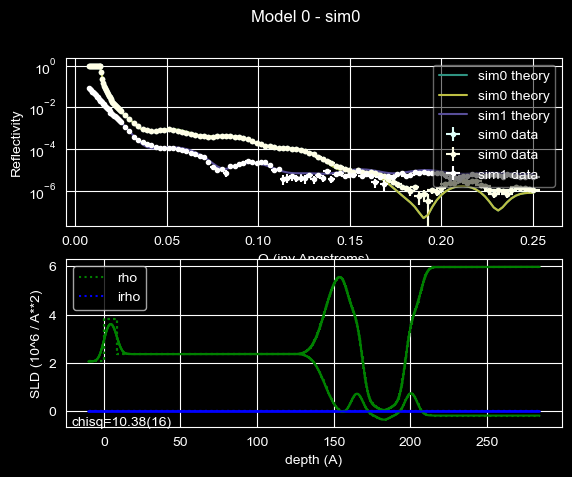

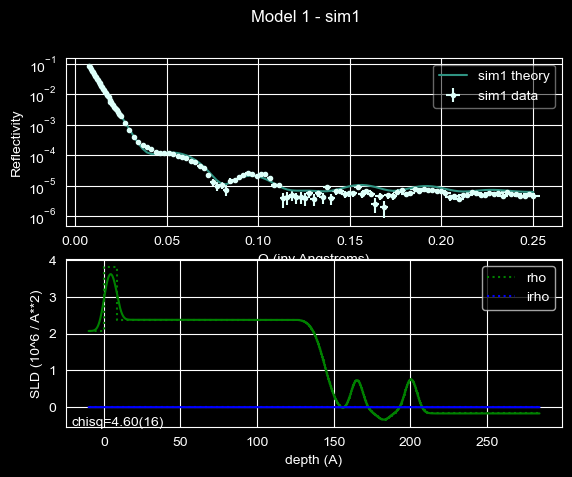

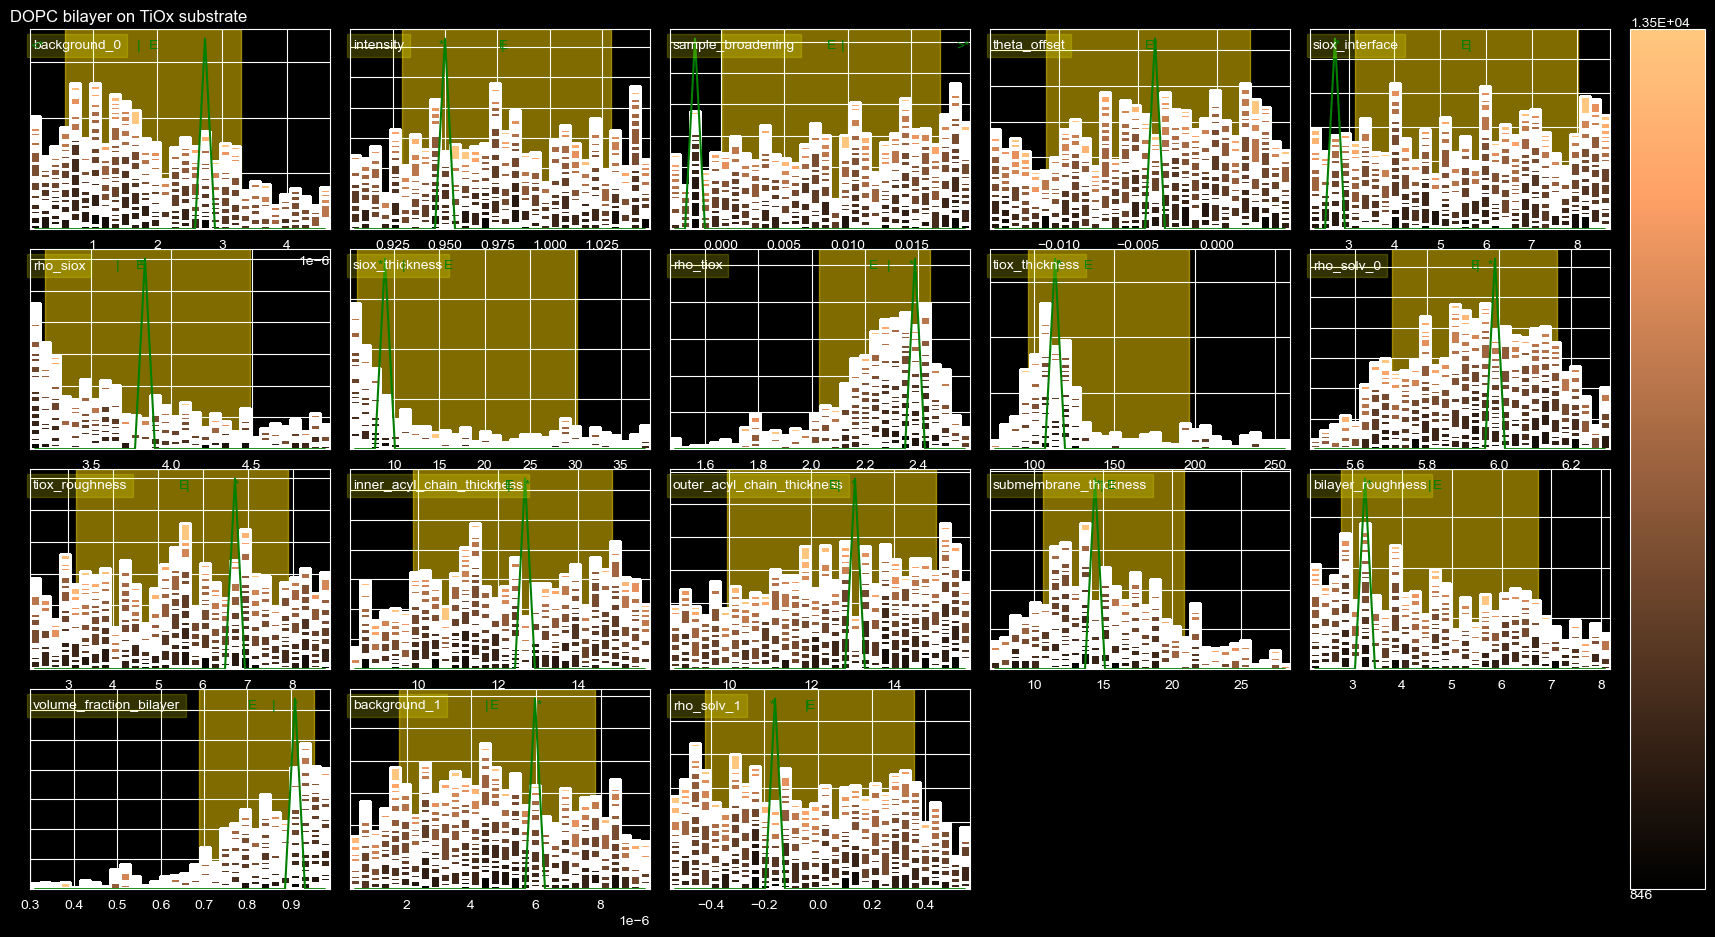

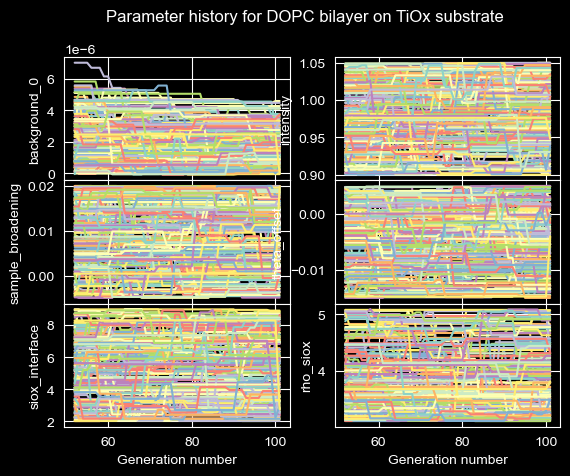

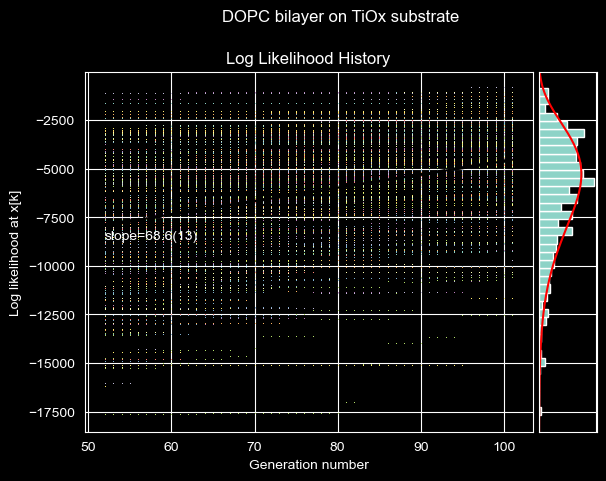

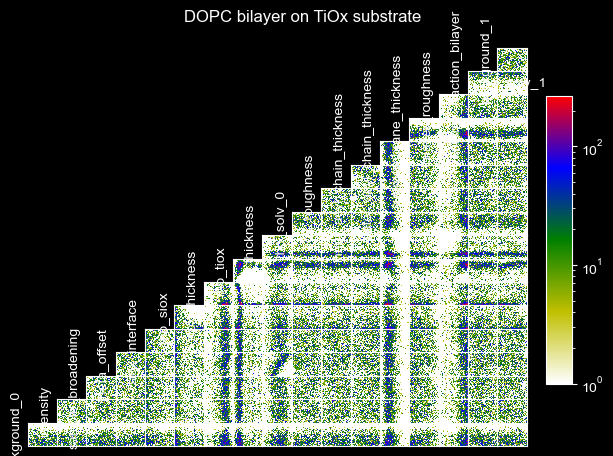

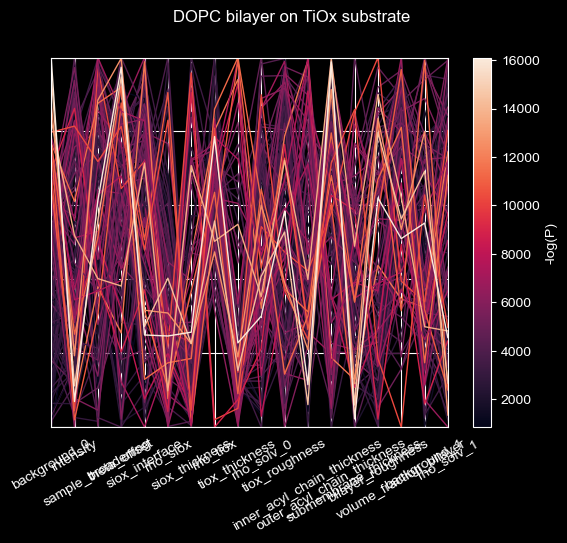

In [3]:
shutil.copyfile('ch060.refl', 'sim1.dat')
shutil.copyfile('ch061.refl', 'sim0.dat')

setupdir = os.getcwd()
store = "T"
runfile = "ssblm"
fitsource = "refl1d"
if not os.path.isdir(store):
    os.mkdir(store)
burn = 50
steps = 50

fit_object = molstat.CMolStat(fitsource=fitsource, spath=setupdir, mcmcpath=store, runfile=runfile, state=None, problem=None)
fit_object.Interactor.fnRunMCMC(burn, steps, batch=False)

# Defining Simulation Model Parameters

* Requires values for all model parameters

In [4]:
%%writefile simpar.dat
background_0 1.03489e-06
intensity 1.0
sample_broadening 0
theta_offset 0.0
siox_interface 6.85069
rho_siox 3.39556
siox_thickness 14.9832
rho_tiox 2.32129
tiox_thickness 1100.913
tiox_roughness 6.8149
inner_acyl_chain_thickness 11.1605
outer_acyl_chain_thickness 13.6487
submembrane_thickness 13.9116
bilayer_roughness 4.84472
volume_fraction_bilayer 0.906858
rho_solv_0 -0.56
background_1 3.95582e-06
rho_solv_1 -0.550133
prefactor 2.58496

Overwriting simpar.dat


In [10]:
sim_data = fit_object.fnSimulateData(qrangefromfile=True)

                           par        value
0                 background_0     0.000001
1                    intensity     1.000000
2            sample_broadening     0.000000
3                 theta_offset     0.000000
4               siox_interface     6.850690
5                     rho_siox     3.395560
6               siox_thickness    14.983200
7                     rho_tiox     2.321290
8               tiox_thickness  1100.913000
9               tiox_roughness     6.814900
10  inner_acyl_chain_thickness    11.160500
11  outer_acyl_chain_thickness    13.648700
12       submembrane_thickness    13.911600
13           bilayer_roughness     4.844720
14     volume_fraction_bilayer     0.906858
15                  rho_solv_0    -0.560000
16                background_1     0.000004
17                  rho_solv_1    -0.550133
18                   prefactor     2.584960
None


/Users/frank/Documents/programming/scattertools/scattertools/support/molstat.py:927: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  diModelPars[parameter] = simpar[simpar.par == parameter].iloc[0][1]


KeyboardInterrupt: 

Font 'default' does not have a glyph for '\ufdff' [U+fdff], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ufdff' [U+fdff], substituting with a dummy symbol.


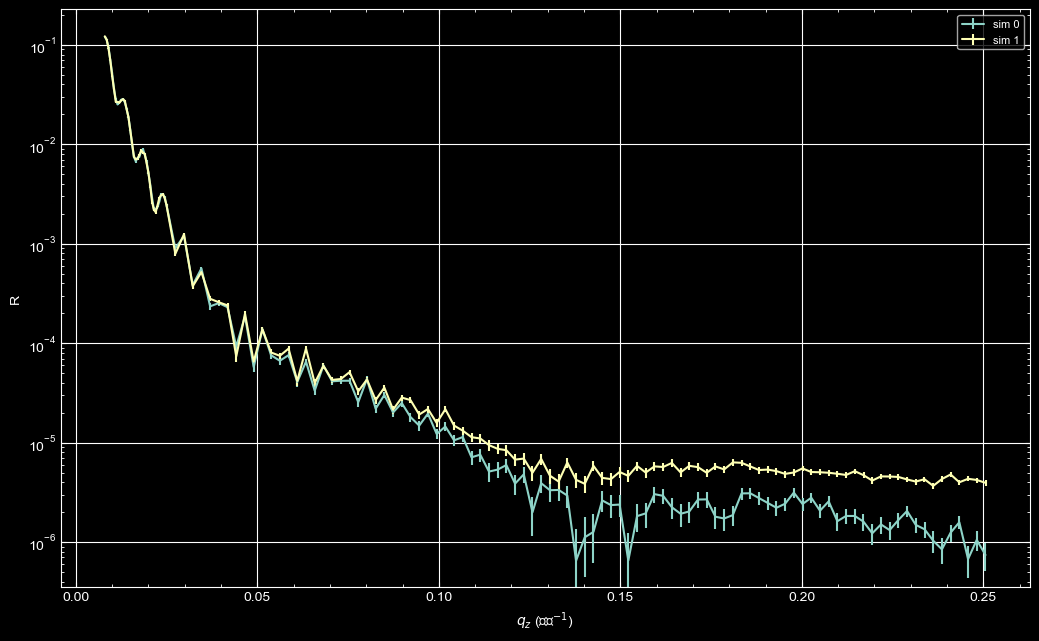

In [7]:
import pandas
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

i = 0
while os.path.isfile('sim' + str(i) + '.dat'):
    simdata = pandas.read_csv('sim' + str(i) + '.dat', sep=' ', skip_blank_lines=True,comment='#', names=['Q', 'R', 'dR', 'dQ'])
    ax.errorbar(simdata['Q'], simdata['R'], simdata['dR'], label="sim " + str(i))
    i += 1

ax.legend(fontsize=8)
ax.set_ylabel("R", fontsize=10)
ax.set_yscale('log')
ax.minorticks_on()
ax.tick_params(which="both", direction="in", labelsize=10)
ax.tick_params(bottom=True, top=True, left=True, right=True, which="both")
ax.set_xlabel("$q_z$ (﷿﷿$^{-1}$)", fontsize=10)
ax.figure.set_size_inches(12.5, 7.5)
plt.savefig(store + "/model_comparison.png", facecolor="white")
plt.show()